# E-커머스 로그 데이터 분석

## 1. 프로젝트 개요

### 1-1 분석 목적
E-커머스 사용자 행동 로그 데이터를 이용해  
구매 전환 퍼널 구조 정의 및 전환율 개선을 위한 인사이트 도출해보는 목적

### 1-2 분석 목표
- 구매 전환 퍼널 구조 정의
- 카테고리별 전환 구조 분석

## 2. 환경 설정 및 분석 준비

In [49]:
# 프로젝트 루트 경로 유지
from pathlib import Path

BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

In [50]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [51]:
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

## 3. 데이터 구조 및 품질 확인(수정)

In [52]:
df = pd.read_csv(BASE_DIR/"data"/"2019-Dec.csv")

In [53]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,1487580005268456287,NaN,f.o.x,6.27,576802932,51d85cb0-897f-48d2-918b-ad63965c12dc
1,2019-12-01 00:00:00 UTC,view,5764655,1487580005411062629,NaN,cnd,29.05,412120092,8adff31e-2051-4894-9758-224bfa8aec18
2,2019-12-01 00:00:02 UTC,cart,4958,1487580009471148064,NaN,runail,1.19,494077766,c99a50e8-2fac-4c4d-89ec-41c05f114554
3,2019-12-01 00:00:05 UTC,view,5848413,1487580007675986893,NaN,freedecor,0.79,348405118,722ffea5-73c0-4924-8e8f-371ff8031af4
4,2019-12-01 00:00:07 UTC,view,5824148,1487580005511725929,NaN,NaN,5.56,576005683,28172809-7e4a-45ce-bab0-5efa90117cd5
...,...,...,...,...,...,...,...,...,...
3533281,2019-12-31 23:59:39 UTC,view,5683350,1487580005671109489,NaN,masura,2.84,536812729,e4a2d47c-a956-4c46-8176-745f52ea664b
3533282,2019-12-31 23:59:46 UTC,view,5888097,1487580013388628160,NaN,shik,179.05,503658154,2dde9867-9e71-4a64-880d-aa68b66aae6d
3533283,2019-12-31 23:59:51 UTC,view,59975,1487580012096782476,NaN,NaN,7.14,595414541,4c6d80bb-5dd3-4fbb-b592-187b51db2753
3533284,2019-12-31 23:59:52 UTC,view,5775982,1783999063314661546,NaN,NaN,11.90,397780878,7e8a2b85-153a-44eb-a71f-b748fde14fcc


In [54]:
df['event_time']

0          2019-12-01 00:00:00 UTC
1          2019-12-01 00:00:00 UTC
2          2019-12-01 00:00:02 UTC
3          2019-12-01 00:00:05 UTC
4          2019-12-01 00:00:07 UTC
                    ...           
3533281    2019-12-31 23:59:39 UTC
3533282    2019-12-31 23:59:46 UTC
3533283    2019-12-31 23:59:51 UTC
3533284    2019-12-31 23:59:52 UTC
3533285    2019-12-31 23:59:57 UTC
Name: event_time, Length: 3533286, dtype: str

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3533286 entries, 0 to 3533285
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 242.6 MB


In [56]:
df['category_code'].unique()

<StringArray>
[                                     nan,
                'furniture.bathroom.bath',
          'appliances.environment.vacuum',
                    'stationery.cartrige',
          'furniture.living_room.cabinet',
                          'apparel.glove',
                        'accessories.bag',
               'accessories.cosmetic_bag',
        'appliances.personal.hair_cutter',
            'furniture.living_room.chair',
 'appliances.environment.air_conditioner']
Length: 11, dtype: str

In [57]:
df['event_type'].unique()

<StringArray>
['remove_from_cart', 'view', 'cart', 'purchase']
Length: 4, dtype: str

In [58]:
df['event_type'].value_counts()

event_type
view                1728331
cart                 927124
remove_from_cart     664655
purchase             213176
Name: count, dtype: int64

#### 데이터 확인 결과
- 사용자가 구매로 가거나 이탈 구조를 파악하기 위한 분석 데이터
- 2019년 12월 1일~12월 31일 데이터 기간으로 총 **3,533,285**개의 데이터 존재
- 카테로그가 크게 **furniture(가구)**, **appliances(가전제품)**, **stationery(문구)**,**apparel(의류)**,**accessories(액세서리)** 로 나뉘어져있음.
- Log타입으로는 **View(상품 보기)**, **Cart(장바구니)**, **Remove_from_cart(장바구니에서 빼기)**, **Purchase(구매)** 로 구성되어있음


## 4. 데이터 전처리

### 4-1 필요한 칼럼들만 사용

In [59]:
df_1 = df[["user_id",
           "event_time",
           "event_type",
           "product_id",
           "category_code",
           "price"]].copy()
df_1

,user_id,event_time,event_type,product_id,category_code,price
0,576802932,2019-12-01 00:00:00 UTC,remove_from_cart,5712790,NaN,6.27
1,412120092,2019-12-01 00:00:00 UTC,view,5764655,NaN,29.05
2,494077766,2019-12-01 00:00:02 UTC,cart,4958,NaN,1.19
3,348405118,2019-12-01 00:00:05 UTC,view,5848413,NaN,0.79
4,576005683,2019-12-01 00:00:07 UTC,view,5824148,NaN,5.56
...,...,...,...,...,...,...
3533281,536812729,2019-12-31 23:59:39 UTC,view,5683350,NaN,2.84
3533282,503658154,2019-12-31 23:59:46 UTC,view,5888097,NaN,179.05
3533283,595414541,2019-12-31 23:59:51 UTC,view,59975,NaN,7.14
3533284,397780878,2019-12-31 23:59:52 UTC,view,5775982,NaN,11.90


### 4-2 요일 칼럼 추가

In [60]:
df_1["event_time"] = pd.to_datetime(df_1["event_time"])
df_1["weekday"] = df_1["event_time"].dt.day_name()

### 4-3 카테고리 분류 및 한글 맵핑

In [61]:
df_1["category"] = df_1["category_code"].str.split(".").str[0]
df_1

,user_id,event_time,event_type,product_id,category_code,price,weekday,category
0,576802932,2019-12-01 00:00:00+00:00,remove_from_cart,5712790,NaN,6.27,Sunday,NaN
1,412120092,2019-12-01 00:00:00+00:00,view,5764655,NaN,29.05,Sunday,NaN
2,494077766,2019-12-01 00:00:02+00:00,cart,4958,NaN,1.19,Sunday,NaN
3,348405118,2019-12-01 00:00:05+00:00,view,5848413,NaN,0.79,Sunday,NaN
4,576005683,2019-12-01 00:00:07+00:00,view,5824148,NaN,5.56,Sunday,NaN
...,...,...,...,...,...,...,...,...
3533281,536812729,2019-12-31 23:59:39+00:00,view,5683350,NaN,2.84,Tuesday,NaN
3533282,503658154,2019-12-31 23:59:46+00:00,view,5888097,NaN,179.05,Tuesday,NaN
3533283,595414541,2019-12-31 23:59:51+00:00,view,59975,NaN,7.14,Tuesday,NaN
3533284,397780878,2019-12-31 23:59:52+00:00,view,5775982,NaN,11.90,Tuesday,NaN


In [62]:
df_1['category'].unique()

array([nan, 'furniture', 'appliances', 'stationery', 'apparel',
       'accessories'], dtype=object)

In [63]:
category_map = {
    "furniture" : "가구",
    "appliances" : "가전제품",
    "stationery" : "문구",
    "apparel" : "의류",
    "accessories" : "악세서리"
}

In [ ]:
df_1.loc[:,"category_kor"] = df_1["category"].map(category_map)

In [65]:
df_1['category_kor'].unique()

<StringArray>
[nan, '가구', '가전제품', '문구', '의류', '악세서리']
Length: 6, dtype: str

In [66]:
df_1['category_kor'] = df_1['category_kor'].fillna('기타')

## 5. 데이터 분석

### 5-1 퍼널 분석

In [67]:
user_event = (df_1.groupby(['user_id','event_type'])
              .size()
              .unstack(fill_value=0)
              .reset_index()
              )
user_event

event_type,user_id,cart,purchase,remove_from_cart,view
0,1180452,0,0,0,1
1,2963072,7,0,0,17
2,4661182,2,0,2,3
3,4891613,0,0,0,1
4,6217356,0,0,0,1
...,...,...,...,...,...
370149,595413843,0,0,0,1
370150,595413976,0,0,0,1
370151,595414210,0,0,0,1
370152,595414257,0,0,0,1


In [68]:
user_event["viewed"] = user_event["view"] > 0
user_event["carted"] = user_event["cart"] > 0
user_event["purchased"] = user_event["purchase"] > 0

In [69]:
funnel_counts = {
    "View": user_event["viewed"].sum(),
    "Cart": user_event[user_event["viewed"]]["carted"].sum(),
    "Purchase": user_event[user_event["carted"]]["purchased"].sum()
}

funnel_df = pd.DataFrame.from_dict(
    funnel_counts, orient="index", columns=["유저수"]
)

funnel_df

,유저수
View,358212
Cart,72359
Purchase,25290


In [70]:
#전환율
funnel_df["전환율"] = (
    funnel_df["유저수"] / funnel_df["유저수"].shift(1)
)

funnel_df

,유저수,전환율
View,358212,NaN
Cart,72359,0.202000
Purchase,25290,0.349507


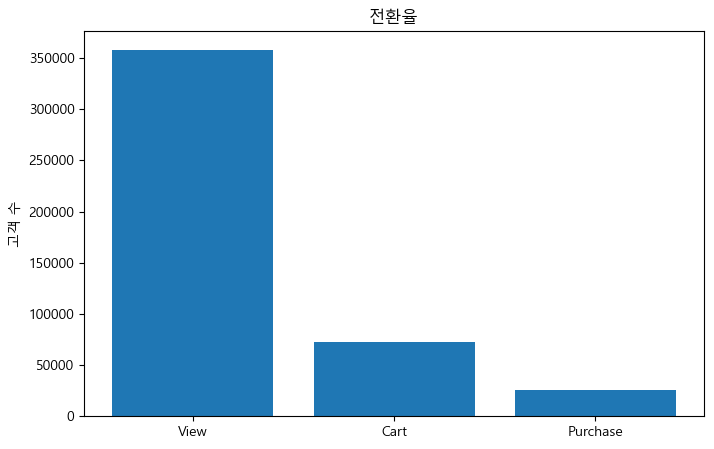

In [71]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_df.index, funnel_df["유저수"])
plt.title("전환율")
plt.ylabel("고객 수")
plt.show()

In [72]:
funnel_df["이탈율"] = 1 - funnel_df["전환율"]
funnel_df

,유저수,전환율,이탈율
View,358212,NaN,NaN
Cart,72359,0.202000,0.798000
Purchase,25290,0.349507,0.650493


View -> Cart 전환율 : 약 20.2%  
Cart -> Purchase 전환율 : 약 34.95%

### 5-2 요일별 카테고리 분석 

In [73]:
df_vp = df_1[df_1["event_type"].isin(["view", "purchase"])]

In [74]:
weekday_cat_counts = (
    df_vp
    .groupby(["weekday", "category_kor", "event_type"])
    .size()
    .reset_index(name="count")
)

In [75]:
pivot = weekday_cat_counts.pivot_table(
    index="weekday",
    columns=["category_kor", "event_type"],
    values="count",
    fill_value=0
)

In [76]:
pivot = pivot.reindex(weekday_order)

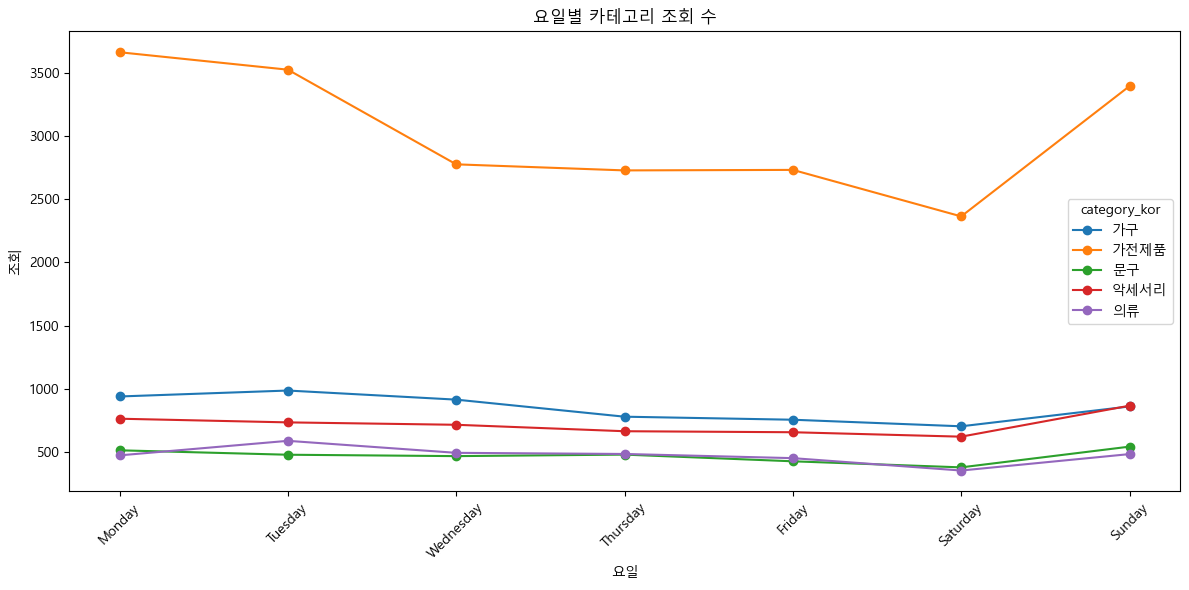

<Figure size 640x480 with 0 Axes>

In [81]:
#기타 값이 너무 커서 제외
view_pivot = (
    df_vp[(df_vp["event_type"] == "view") & (df_vp["category_kor"] != "기타")]
    .groupby(["weekday", "category_kor"])
    .size()
    .unstack(fill_value=0)
    .reindex(weekday_order)
)

view_pivot.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)


plt.title("요일별 카테고리 조회 수")
plt.xlabel("요일")
plt.ylabel("조회")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

대부분 일요일에 조회수가 증가하고 수요일에 조회수가 감소

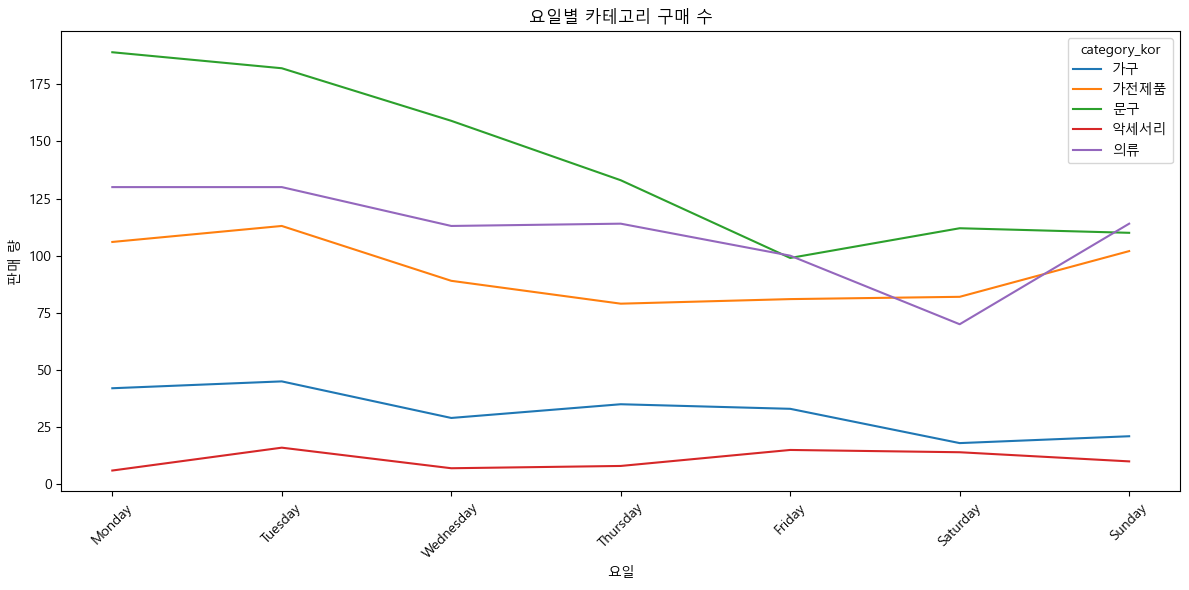

In [83]:
purchase_pivot = (
    df_vp[(df_vp["event_type"] == "purchase") & (df_vp["category_kor"] != "기타")]
    .groupby(["weekday", "category_kor"])
    .size()
    .unstack(fill_value=0)
    .reindex(weekday_order)
)

purchase_pivot.plot(
    kind="line",
    figsize=(12, 6)
)

plt.title("요일별 카테고리 구매 수")
plt.xlabel("요일")
plt.ylabel("판매 량")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5-3 카테고리별 분석

In [84]:
user_category = (
    df_1
    .groupby(["category_kor", "user_id", "event_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

user_category.head()

event_type,category_kor,user_id,cart,purchase,remove_from_cart,view
0,가구,30800521,0,0,0,1
1,가구,56612519,2,0,2,3
2,가구,80310232,1,0,0,2
3,가구,80577370,1,0,1,0
4,가구,88525648,0,0,0,2


In [85]:
user_category["viewed"] = user_category["view"] > 0
user_category["carted"] = user_category["cart"] > 0
user_category["purchased"] = user_category["purchase"] > 0

In [86]:
category_funnel = (
    user_category
    .groupby("category_kor")
    .agg(
        view_users=("viewed", "sum"),
        cart_users=("carted", "sum"),
        purchase_users=("purchased", "sum")
    )
)

In [87]:
category_funnel["view_to_cart"] = (
    category_funnel["cart_users"] / category_funnel["view_users"]
)

category_funnel["cart_to_purchase"] = (
    category_funnel["purchase_users"] / category_funnel["cart_users"]
)

category_funnel["view_to_purchase"] = (
    category_funnel["purchase_users"] / category_funnel["view_users"]
)

In [88]:
# 최소 트래픽 기준 (노이즈 제거)
category_funnel = category_funnel[
    category_funnel["view_users"] >= 500]


In [89]:
# 전체 구매 전환율 기준 정렬
category_funnel.sort_values(
    "view_to_purchase", ascending=False
).head(10)

,view_users,cart_users,purchase_users,view_to_cart,cart_to_purchase,view_to_purchase
category_kor,,,,,,
의류,1639,1440,674,0.878585,0.468056,0.411226
문구,1769,955,439,0.539853,0.459686,0.248163
가전제품,7466,1575,550,0.210956,0.349206,0.073667
기타,350423,82738,25411,0.236109,0.307126,0.072515
가구,3032,675,179,0.222625,0.265185,0.059037
악세서리,2271,195,62,0.085865,0.317949,0.027301


In [90]:
funnel_cols = ["view_users", "cart_users", "purchase_users"]

conversion = (
    category_funnel[funnel_cols]
    .div(category_funnel[funnel_cols].shift(1, axis=1))
)

conversion.columns = ["view_to_cart", "cart_to_purchase", "view_to_purchase"]
category_funnel = pd.concat([category_funnel, conversion], axis=1)

In [91]:
category_funnel = category_funnel.loc[:, ~category_funnel.columns.duplicated()]

In [92]:
plot_df = category_funnel.copy()

In [93]:
plot_df = plot_df[plot_df["view_users"] >= 500]
plot_df = plot_df.sort_values("view_to_purchase", ascending=False)

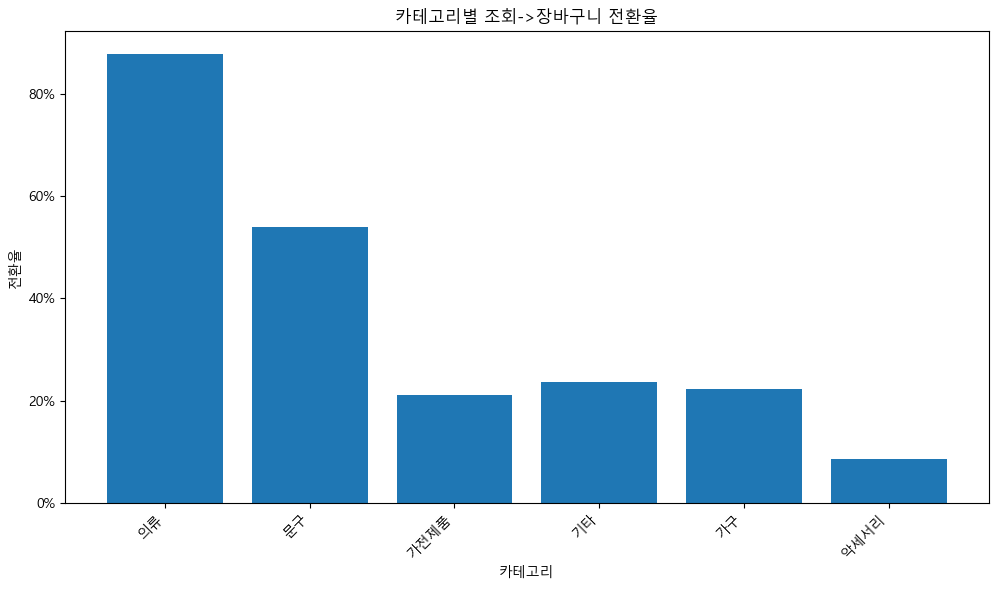

In [94]:
plt.figure(figsize=(10, 6))
plt.bar(plot_df.index, plot_df["view_to_cart"])
plt.xticks(rotation=45, ha="right")
plt.title("카테고리별 조회->장바구니 전환율")
plt.ylabel("전환율")
plt.xlabel("카테고리")
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

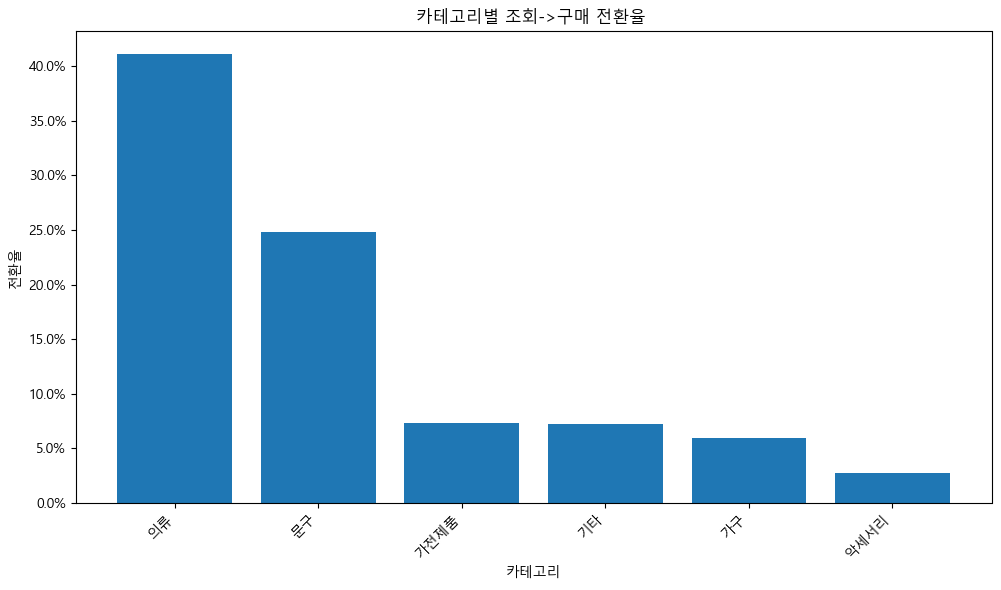

In [95]:
plt.figure(figsize=(10, 6))
plt.bar(plot_df.index, plot_df["view_to_purchase"])
plt.xticks(rotation=45, ha="right")
plt.title("카테고리별 조회->구매 전환율 ")
plt.ylabel("전환율")
plt.xlabel("카테고리")
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

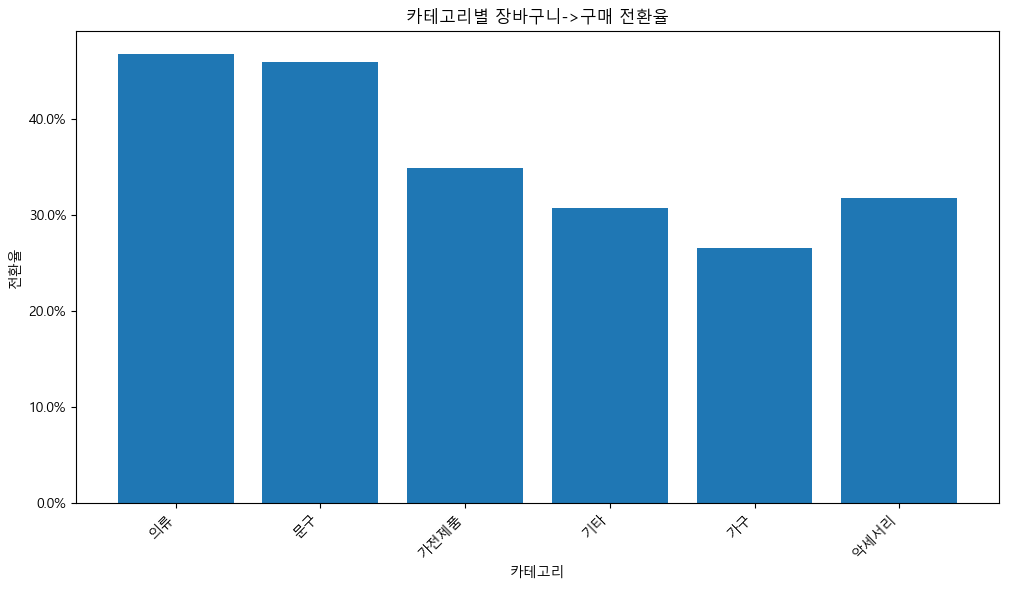

In [96]:
plt.figure(figsize=(10, 6))
plt.bar(plot_df.index, plot_df["cart_to_purchase"])
plt.xticks(rotation=45, ha="right")
plt.title("카테고리별 장바구니->구매 전환율")
plt.ylabel("전환율")
plt.xlabel("카테고리")
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

- 카테고리별 전환율 편차가 큼
- 일부 카테고리는 view 대비 purchase 전환율이 매우 높음.
- 고전환 카테고리는 마케팅 집중 대상군으로 활용 가능함.
- 저전환 카테고리는 UX 구조 또는 상품 구조 개선 필요함.

## 6. 결론 및 전략 제안

### 핵심 인사이트
- 구매 전환 퍼널 구조상 view → cart 구간에서 대규모 이탈 발생
- cart → purchase 단계 또한 주요 병목 구간으로 확인됨
- 카테고리별 구매 전환 구조 차이가 명확히 존재
- 일부 고전환 카테고리가 전체 구매 전환을 견인

### 전략 제안 (Business Action Plan)

#### 마케팅 전략
- 고전환 카테고리 중심 광고 집중 전략
- 장바구니 이탈 사용자 리타겟팅 캠페인 적용
- 재방문 유도 프로모션 구조 설계

#### 상품 전략
- 고전환 상품 상단 배치 구조 설계
- 저전환 상품 구조 개선 또는 리포지셔닝
- 카테고리 구조 단순화 전략